In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [27]:
example_data_file = 'pub_trend_example_data.csv'

data = pd.read_csv(example_data_file)
data.head()

,Year,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
0,1990,21,25,0,0,2,1,0,0
1,1991,41,50,0,0,9,4,0,1
2,1992,72,56,0,0,15,4,1,0
3,1993,128,82,0,0,14,8,1,0
4,1994,247,135,0,0,17,18,3,1


Other options besides reading tabular data -> survey

Here's how we easily get the rows and columns:

In [28]:
columns = data.columns
index = data.index

print(columns)
print(index)

Index(['Year', 'Viral Vectors', 'Lipid Nanoparticles', 'Metal Nanoparticles',
       'Carbon Nanomaterials', 'Hydrogels', 'Synthetic Polymer Nanostructures',
       'Peptide Nanostructures', 'Polysaccharide Nanostructures'],
      dtype='object')
RangeIndex(start=0, stop=36, step=1)


By default when loading a dataset the index is just a range of integers from 0 to the total number of rows in your spreadsheet, but we can change this later.

In [29]:
data['Hydrogels'].tail(5)

31    1586
32    1836
33    1972
34    2195
35     423
Name: Hydrogels, dtype: int64

We can select a subset of our original dataset including only specified columns with `[[]]`

In [30]:
data[['Year', 'Hydrogels', 'Synthetic Polymer Nanostructures']].head()

,Year,Hydrogels,Synthetic Polymer Nanostructures
0,1990,2,1
1,1991,9,4
2,1992,15,4
3,1993,14,8
4,1994,17,18


We can also select a row slice by calling its index:

In [31]:
data[0:3]

,Year,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
0,1990,21,25,0,0,2,1,0,0
1,1991,41,50,0,0,9,4,0,1
2,1992,72,56,0,0,15,4,1,0


Sometimes we intend for a column of our `DataFrame` to serve as the index instead of the one `pandas` generates by default. We can specify which column should instead be the index upon reading in our data file:

In [38]:
data = pd.read_csv('pub_trend_example_data.csv', index_col='Year')
data.head()

,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
Year,,,,,,,,
1990,21,25,0,0,2,1,0,0
1991,41,50,0,0,9,4,0,1
1992,72,56,0,0,15,4,1,0
1993,128,82,0,0,14,8,1,0
1994,247,135,0,0,17,18,3,1


In [37]:
print(data.index)
print(data.columns)

Index([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int64', name='Year')
Index(['Viral Vectors', 'Lipid Nanoparticles', 'Metal Nanoparticles',
       'Carbon Nanomaterials', 'Hydrogels', 'Synthetic Polymer Nanostructures',
       'Peptide Nanostructures', 'Polysaccharide Nanostructures'],
      dtype='object')


Go through basic slicing, .loc/.iloc, boolean, etc.

For more precise selection and slicing, we can use the `DataFrame.loc` method to select columns and rows by label:

In [39]:
data.loc[2007]

Viral Vectors                       1022
Lipid Nanoparticles                  442
Metal Nanoparticles                   36
Carbon Nanomaterials                 105
Hydrogels                            226
Synthetic Polymer Nanostructures     300
Peptide Nanostructures               121
Polysaccharide Nanostructures        118
Name: 2007, dtype: int64

In [ ]:
# Equivalent to data['Peptide Nanostructures']:
data.loc[:, 'Peptide Nanostructures']

Year
1990       0
1991       0
1992       1
1993       1
1994       3
1995       4
1996       9
1997       7
1998       9
1999       8
2000      10
2001      14
2002      21
2003      23
2004      32
2005      68
2006      95
2007     121
2008     166
2009     213
2010     251
2011     353
2012     411
2013     533
2014     579
2015     660
2016     776
2017     911
2018    1005
2019     933
2020     982
2021    1012
2022    1027
2023     883
2024     913
2025     197
Name: Peptide Nanostructures, dtype: int64

We can use the `DataFrame.loc` method to retrieve a value from a specific row label, column label combination:

In [ ]:
data.loc[2007, 'Peptide Nanostructures']

# Note: for large datasets of numerical data, the speed-optimized df.at[] method may be used instead

np.int64(121)

In [44]:
data.loc[2000:2003, 'Peptide Nanostructures']

Year
2000    10
2001    14
2002    21
2003    23
Name: Peptide Nanostructures, dtype: int64

In [54]:
data.loc[2000:2003, ['Peptide Nanostructures', 'Polysaccharide Nanostructures']]

,Peptide Nanostructures,Polysaccharide Nanostructures
Year,,
2000,10,13
2001,14,12
2002,21,17
2003,23,24


Sometimes it's more useful to select/slice data from index values instead of labels. In this case, we can use the `DataFrame.iloc` method:

In [48]:
# Equivalent to data.loc[2007] in our case:
data.iloc[17]

Viral Vectors                       1022
Lipid Nanoparticles                  442
Metal Nanoparticles                   36
Carbon Nanomaterials                 105
Hydrogels                            226
Synthetic Polymer Nanostructures     300
Peptide Nanostructures               121
Polysaccharide Nanostructures        118
Name: 2007, dtype: int64

In [ ]:
# Equivalent to both data.loc[:, 'Peptide Nanostructures'] and data['Peptide Nanostructures']:
data.iloc[:, 6]

Year
1990       0
1991       0
1992       1
1993       1
1994       3
1995       4
1996       9
1997       7
1998       9
1999       8
2000      10
2001      14
2002      21
2003      23
2004      32
2005      68
2006      95
2007     121
2008     166
2009     213
2010     251
2011     353
2012     411
2013     533
2014     579
2015     660
2016     776
2017     911
2018    1005
2019     933
2020     982
2021    1012
2022    1027
2023     883
2024     913
2025     197
Name: Peptide Nanostructures, dtype: int64

In [50]:
data.iloc[17, 6]

# Note: similarly to df.at, the df.iat method uses a much faster algorithm to return the same result

np.int64(121)

In [52]:
data.iloc[10:14, 6]

# Note: Unlike df.loc, df.iloc uses standard Python indexing rules where the final position is not inclusive

Year
2000    10
2001    14
2002    21
2003    23
Name: Peptide Nanostructures, dtype: int64

In [53]:
data.iloc[10:14, [6, 7]]

# Note: this is equivalent to data.iloc[10:14, 6:8]

,Peptide Nanostructures,Polysaccharide Nanostructures
Year,,
2000,10,13
2001,14,12
2002,21,17
2003,23,24


In [ ]:
data.describe()

,Viral Vectors,Lipid Nanoparticles,Metal Nanoparticles,Carbon Nanomaterials,Hydrogels,Synthetic Polymer Nanostructures,Peptide Nanostructures,Polysaccharide Nanostructures
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,955.888889,950.805556,228.777778,460.777778,538.333333,746.361111,339.750000,459.805556
std,490.405475,891.832490,319.555058,579.638760,633.403234,817.109160,391.614269,561.386336
min,21.000000,25.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
25%,603.000000,269.750000,0.000000,1.750000,50.750000,24.250000,9.000000,7.500000
50%,1035.500000,542.500000,41.000000,128.000000,257.000000,330.000000,143.500000,148.500000
75%,1212.000000,1571.750000,335.250000,921.250000,812.500000,1639.750000,689.000000,889.000000
max,1821.000000,2859.000000,951.000000,1521.000000,2195.000000,2190.000000,1027.000000,1543.000000


[Matplotlib pie chart](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html)

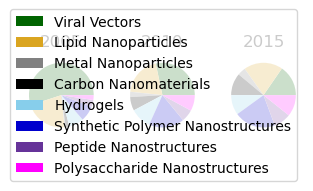

In [ ]:
from matplotlib.patches import Patch

data = pd.read_csv(example_data_file, index_col='Year')

pubs_2005 = data.loc[2005]
pubs_2010 = data.loc[2010]
pubs_2015 = data.loc[2015]

colors = ['darkgreen', 'goldenrod', 'grey', 'black', 'skyblue',
          'mediumblue', 'rebeccapurple', 'magenta']
patches = [Patch(facecolor=col) for col in colors]

fig, axs = plt.subplot_mosaic([['pie1', 'pie2', 'pie3', '.']],
                              figsize=(6, 12),
                              width_ratios=(1, 1, 1, 2))

axs['pie1'].pie(pubs_2005, colors=colors)
axs['pie1'].set_title('2005')

axs['pie2'].pie(pubs_2010, colors=colors)
axs['pie2'].set_title('2010')

axs['pie3'].pie(pubs_2015, colors=colors)
axs['pie3'].set_title('2015')
axs['pie3'].legend(patches, data.columns, loc='center right')

- [10-Minute Guide to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html)